# LOAD LIBRARIES

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [35]:
START_DATE, END_DATE = '2023-11-08', '2024-07-25' # Wheat
TARGET_FLUX = 'FN2O'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = True
ADD_ID = True
UNDERSAMPLE = True
PERMUTATION_SEL = False
RFE_SEL = True

# LOAD DATA

In [36]:
data = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data = data.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data['id'] = range(0, len(data))

data

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.472 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,prec,ta,timesince_prec,vpd,...,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,5.333333,12.0,0.180179,...,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.564360,0.573172,-0.047840,-0.181710,-0.177446,0.052573,-1.360142,-0.071378,0.477293,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,5.966667,13.0,0.210078,...,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.022171,0.720981,-0.202111,-0.048345,0.008988,0.015635,-1.939471,0.000852,0.241896,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,5.833333,14.0,0.209377,...,-1.423575,-1.251268,0.154263,0.054827,2.845686,-1.730258,0.304878,0.755972,-0.137978,0.079340,0.129646,-0.687567,0.201061,0.512755,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,5.866667,15.0,0.212335,...,-1.456775,-1.194985,0.190084,0.205121,2.216312,-1.685342,0.385222,0.331593,-0.220338,-0.022307,0.288816,-0.600509,0.215442,0.568651,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,5.766667,16.0,0.210251,...,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.500100,0.629110,0.868842,-0.175981,-0.027153,0.167790,-0.600174,0.027040,0.576383,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-25 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.562339,4.946882,None,None,0.0,16.166667,128.0,0.246013,...,1.979258,0.117887,0.470140,1.934095,0.069588,-0.781542,-0.944345,-0.828950,-0.099631,0.205294,-0.326433,-0.285875,0.167037,-0.173701,12523
2024-07-25 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.656828,4.852393,None,None,0.0,15.766667,129.0,0.218872,...,1.702703,0.001131,0.240362,1.779158,-0.057751,-0.904521,-1.299068,-1.184607,-0.106046,0.163649,-0.343612,-0.287530,-0.037435,-0.212412,12524
2024-07-25 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.671307,4.837914,None,None,0.0,15.700000,130.0,0.207221,...,1.272358,-0.123926,0.233171,1.737272,-0.048307,-1.044708,-1.119899,-1.157502,-0.137013,0.089801,-0.460830,-0.300689,0.009702,-0.200432,12525


# CLEAN DATA

In [37]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data[TARGET]
    .isna()
    .ne(data[TARGET].isna().shift())
    .cumsum()
    .where(data[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data[data[TARGET].notna()]

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

# Remove some variables that cannot mechanistically be related to N2O flux or hard to explain 
# prefix = ('flux_reco', 'flux_h', 'flux_le', 'lai', 'canopy_height', 'sw', 'flux_ch4', 'flux_nee', 'pa', 'rh', 'fert', 'harvest', 'soil_preparation', 'sowing', 'nitrogen_fert', 'ta', 'timesince_sowing', 'crop_n')
# inside = ('0.5')
# to_drop = [c for c in data.columns if c.startswith(prefix) or inside in c]
# data.drop(columns=to_drop, inplace=True)
# print(f"Dropped {len(to_drop)} columns considered not to be relevant for the target based on knowledge: {to_drop}")

# Keep only variables of the chosen categories
# prefix = ('wfps', 'ts', 'prec', 'flux_gpp', 'n_decay_timed', 'timesince_fert', 'timesince_soil_preparation', 'timesince_harvest', f'flux_{TARGET_FLUX}')
# to_keep = [c for c in data.columns if c.startswith(prefix) and '0.5' not in c]
# data = data[to_keep].copy()

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

def clean_data(df, threshold=0.05):
    """Remove columns with too many missing values and non-numeric columns."""
    dropped_missing = df.columns[df.isna().mean() > threshold].tolist()
    df = df.drop(columns=dropped_missing)
    dropped_non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    df = df.select_dtypes(include=[np.number])
    print(f"\nDropped {len(dropped_missing)} due to missing values: {dropped_missing}")
    print(f"Dropped {len(dropped_non_numeric)} non-numeric columns: {dropped_non_numeric}")
    
    return df

data = clean_data(data)

data

The target variable is FN2O_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 4.583804143126177

Keeping only data when we are highly confident on the parcel attribution

Dropped 4 due to missing values: ['NEE_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0', 'FCH4_L3.3_CUT_50_QCF0']
Dropped 2 non-numeric columns: ['parcel', 'parcel_certainty']


,FN2O_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,prec,ta,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,...,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,0.100302,2.035776,-0.203400,1.832376,0.0,5.966667,13.0,0.210078,6.817496,9.855426,10.933558,38.511337,51.889339,35.429823,21.0,...,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.022171,0.720981,-0.202111,-0.048345,0.008988,0.015635,-1.939471,0.000852,0.241896,1
2023-11-08 01:15:00,0.239428,2.026159,-0.210755,1.815404,0.0,5.833333,14.0,0.209377,6.969578,9.790032,10.941941,38.346531,51.961689,35.631750,21.0,...,-1.423575,-1.251268,0.154263,0.054827,2.845686,-1.730258,0.304878,0.755972,-0.137978,0.079340,0.129646,-0.687567,0.201061,0.512755,2
2023-11-08 02:15:00,0.358358,2.025592,-0.218648,1.806944,0.0,5.766667,16.0,0.210251,7.089032,9.802778,11.114241,38.446839,51.881405,35.604578,21.0,...,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.500100,0.629110,0.868842,-0.175981,-0.027153,0.167790,-0.600174,0.027040,0.576383,4
2023-11-08 03:15:00,0.070120,1.991226,-0.230492,1.760734,0.0,5.400000,18.0,0.212734,7.258470,9.776045,10.794777,38.412783,51.874562,35.653820,21.0,...,-1.743717,-1.250376,-0.069672,0.010304,0.609105,-1.514331,0.425002,1.042137,-0.005165,-0.065745,0.055501,0.100861,0.057352,0.449444,6
2023-11-08 04:15:00,-0.545573,1.818380,-0.152503,1.665877,0.0,4.633333,20.0,0.174974,7.059120,10.027685,10.725005,38.409004,51.873226,35.993931,21.0,...,-1.319282,-0.813456,-0.114923,-0.589170,0.650526,-1.214557,0.525693,1.072204,0.251217,0.064532,0.108497,0.323842,0.325964,0.776480,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-22 17:15:00,0.430606,-0.290069,6.524246,6.234177,0.0,21.966667,14.0,0.685626,22.343701,21.290741,20.215554,42.495615,51.166678,33.326382,30.0,...,0.290741,-1.135556,0.016665,-0.326669,-0.350742,-1.101004,6.425403,5.622711,-1.274613,2.731379,2.272492,0.122500,2.128122,1.836714,12370
2024-07-22 18:15:00,0.311525,0.555313,5.767465,6.322778,0.0,22.316667,16.0,0.775354,22.226295,21.400000,20.271852,42.389464,51.100761,33.311153,30.0,...,0.500000,-1.107407,0.106665,-0.211111,-0.426296,-0.868719,6.232268,5.626720,-0.981354,2.671377,2.236652,-0.169361,2.142724,1.837053,12372
2024-07-23 05:15:00,0.314246,4.520670,0.598910,5.119580,0.0,17.723333,38.0,0.288270,19.620371,20.544445,20.154817,41.628814,50.629021,33.107407,30.0,...,-0.746296,-0.455555,-0.244443,-0.060737,-0.387406,-0.335437,-0.866801,5.558602,-0.205493,-0.537657,2.193722,-0.092647,-0.218976,1.909146,12394


# IMBALANCE HANDLING

## UNDER SAMPLING

Undersampling target data below: 0.311087692


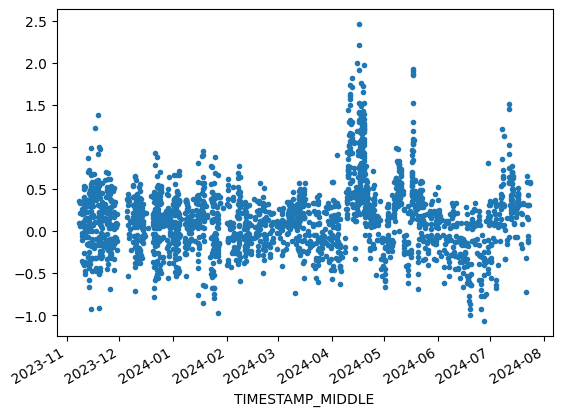

In [38]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.')
    plt.show()


## LOG TRANSFORMATION

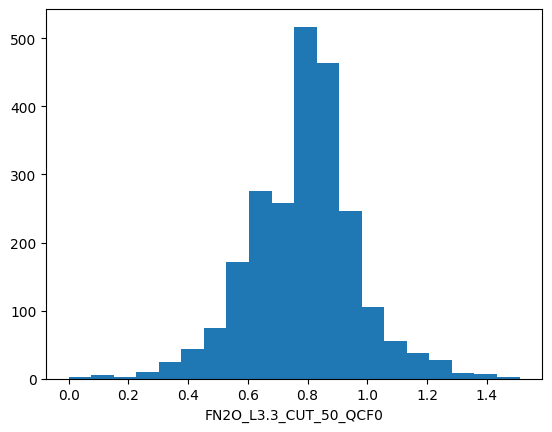

,FN2O_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,prec,ta,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,...,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,0.772865,2.035776,-0.203400,1.832376,0.0,5.966667,13.0,0.210078,6.817496,9.855426,10.933558,38.511337,51.889339,35.429823,21.0,...,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.022171,0.720981,-0.202111,-0.048345,0.008988,0.015635,-1.939471,0.000852,0.241896,1
2023-11-08 02:15:00,0.885426,2.025592,-0.218648,1.806944,0.0,5.766667,16.0,0.210251,7.089032,9.802778,11.114241,38.446839,51.881405,35.604578,21.0,...,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.500100,0.629110,0.868842,-0.175981,-0.027153,0.167790,-0.600174,0.027040,0.576383,4
2023-11-08 11:45:00,0.755965,0.687209,1.610370,2.297578,0.0,9.433333,35.0,0.508871,8.219166,9.405691,9.212877,38.417302,51.938420,36.011344,21.0,...,-1.108148,-1.402914,-1.422082,-2.595901,-2.010428,-0.106256,-0.399017,0.616091,0.008816,0.110672,-0.001470,0.017809,0.946879,0.569824,23
2023-11-08 12:15:00,0.873966,0.684927,1.664430,2.349357,0.0,9.800000,36.0,0.536545,7.895454,9.651937,8.696554,38.497245,51.994515,36.126531,21.0,...,-0.163406,-1.280112,-1.867862,-2.211858,-2.591009,-0.024149,0.141656,0.714828,0.085479,0.206670,0.029224,0.208761,0.690103,0.618725,24
2023-11-08 12:45:00,0.825594,-0.462091,2.825652,2.363561,0.0,9.900000,37.0,0.536497,8.830851,9.612379,8.798609,38.281806,51.965867,36.214424,22.0,...,-0.243047,-1.445586,-1.761413,-2.134949,-2.235121,-0.320615,-0.229530,0.491451,-0.004178,0.076528,0.085516,0.296654,0.784602,0.785454,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-22 17:15:00,0.914796,-0.290069,6.524246,6.234177,0.0,21.966667,14.0,0.685626,22.343701,21.290741,20.215554,42.495615,51.166678,33.326382,30.0,...,0.290741,-1.135556,0.016665,-0.326669,-0.350742,-1.101004,6.425403,5.622711,-1.274613,2.731379,2.272492,0.122500,2.128122,1.836714,12370
2024-07-22 18:15:00,0.865917,0.555313,5.767465,6.322778,0.0,22.316667,16.0,0.775354,22.226295,21.400000,20.271852,42.389464,51.100761,33.311153,30.0,...,0.500000,-1.107407,0.106665,-0.211111,-0.426296,-0.868719,6.232268,5.626720,-0.981354,2.671377,2.236652,-0.169361,2.142724,1.837053,12372
2024-07-23 05:15:00,0.867061,4.520670,0.598910,5.119580,0.0,17.723333,38.0,0.288270,19.620371,20.544445,20.154817,41.628814,50.629021,33.107407,30.0,...,-0.746296,-0.455555,-0.244443,-0.060737,-0.387406,-0.335437,-0.866801,5.558602,-0.205493,-0.537657,2.193722,-0.092647,-0.218976,1.909146,12394


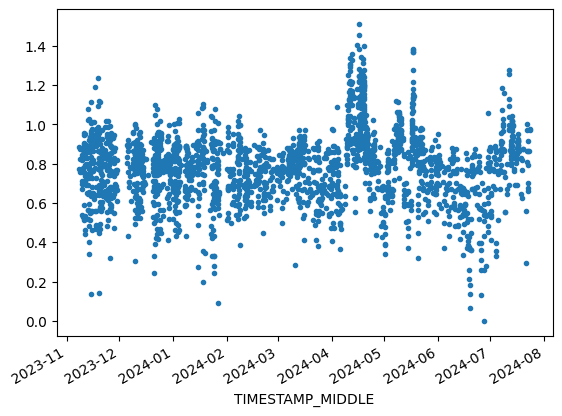

In [39]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

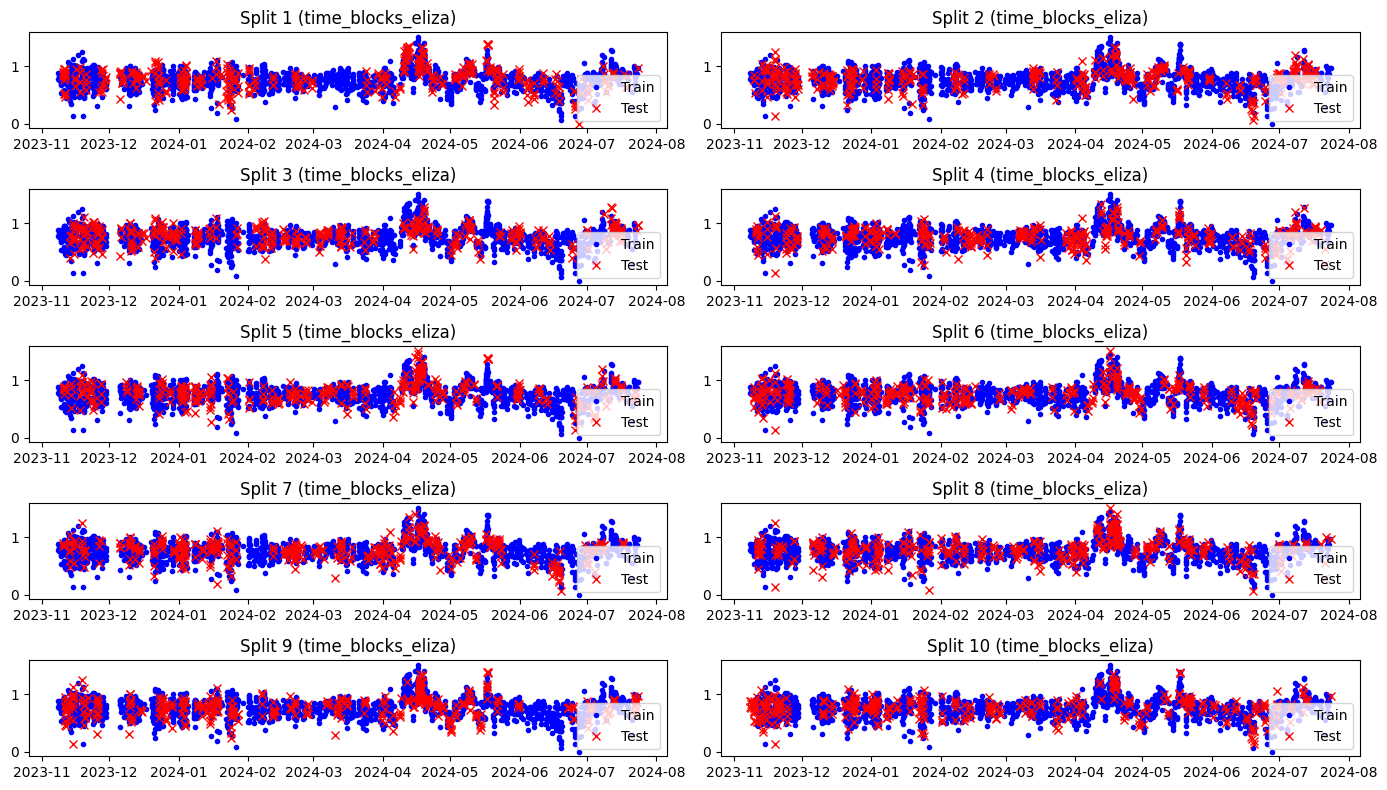

In [40]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block=mean_nan_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits
    
if CROSSVAL_SPLIT == 'custom_time_blocks':
    def create_splits(X, y, n_folds=5, test_fraction=0.2, block_duration='1D',
                    min_gap='6D', buffer_gap='1D', seed=None):
        """
        Time-block CV with buffer and min_gap enforcement, allowing partial blocks to match test_fraction.
        """
        if seed is not None:
            np.random.seed(seed)

        total_rows = len(X)
        total_test_target = int(total_rows * test_fraction)
        all_times = X.index
        block_dur = pd.to_timedelta(block_duration)
        min_gap_dur = pd.to_timedelta(min_gap)
        buffer_gap_dur = pd.to_timedelta(buffer_gap)

        # Generate all possible block start times
        possible_starts = all_times[(all_times + block_dur) <= all_times[-1]]
        splits = []

        for fold in range(n_folds):
            test_indices = set()
            buffer_indices = set()
            selected_blocks = []

            shuffled_starts = np.random.permutation(possible_starts)

            for start_time in shuffled_starts:
                end_time = start_time + block_dur
                buffer_start = start_time - buffer_gap_dur
                buffer_end = end_time + buffer_gap_dur

                # Enforce min_gap between selected test blocks
                if any(abs(pd.Timedelta(start_time - sel).total_seconds()) < min_gap_dur.total_seconds()
                    for sel in selected_blocks):
                    continue

                block_mask = (all_times >= start_time) & (all_times < end_time)
                buffer_mask = (all_times >= buffer_start) & (all_times < buffer_end)

                block_idx = np.where(block_mask)[0]
                buffer_idx = np.where(buffer_mask)[0]

                if len(block_idx) == 0:
                    continue

                # Allow trimming final block if needed
                remaining = total_test_target - len(test_indices)
                if remaining <= 0:
                    break
                if len(block_idx) > remaining:
                    block_idx = block_idx[:remaining]

                # Check again for overlap with buffer
                if any(i in buffer_indices for i in block_idx):
                    continue

                test_indices.update(block_idx)
                buffer_indices.update(buffer_idx)
                selected_blocks.append(start_time)

                if len(test_indices) >= total_test_target:
                    break

            train_indices = sorted(set(range(total_rows)) - test_indices - buffer_indices)
            splits.append((np.array(train_indices), np.array(sorted(test_indices))))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE SELECTION

## Permutation importance

In [41]:
N_REPEATS = 5
N_RANDOMS = 10 
def permutation_importance_selection(X, y, n_repeats=N_REPEATS, n_randoms=N_RANDOMS):
    iteration = 0

    # Generate random features ONCE and keep them throughout the iterations
    np.random.seed(42)  # Ensures reproducibility
    for i in range(n_randoms):
        X[f'random_{i}'] = np.random.permutation(len(X))

    while True:
        iteration += 1
        print(f"Iteration {iteration}: Starting with {X.shape[1] - n_randoms} features")

        model = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1) \
            if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        importance_scores, rmse_scores, r2_scores = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X.iloc[train_idx], y.iloc[train_idx], X.iloc[test_idx], y.iloc[test_idx]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)

            perm_importance = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=42, n_jobs=-1)
            importance_scores.append(perm_importance.importances_mean)
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))

        mean_importance = np.mean(importance_scores, axis=0)
        threshold = np.mean(mean_importance[-n_randoms:])  # Use average of random features as threshold
        
        to_remove = [col for col in X.columns if mean_importance[X.columns.get_loc(col)] < threshold and not col.startswith('random_')]
        to_keep = [col for col in X.columns if col not in to_remove]
        print(f"Iteration {iteration}: Removed {len(to_remove)} features, RMSE: {np.mean(rmse_scores):.4f}, R²: {np.mean(r2_scores):.4f}")
        
        if len(to_remove) == 0:
            break  # Stop when no features are removed

        X = X[to_keep].copy()

    # Remove random features from final selection
    to_keep = [col for col in to_keep if not col.startswith('random_')]
    return to_keep


if PERMUTATION_SEL:
    to_keep = permutation_importance_selection(data.drop(columns=[TARGET]), data[TARGET])
    data = data[to_keep + [TARGET]]
    to_keep

## Recursive feature elimination

In [42]:
def rfe_selection(X, y, cross_val_splits):
    performance = []
    iteration = 0
    features = list(X.columns)
    feature_removal_order = []  # Store removed features and their iteration index

    while len(features) > 1:
        iteration += 1
        rmse_scores, r2_scores, importances = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X[features].iloc[train_idx], y.iloc[train_idx], X[features].iloc[test_idx], y.iloc[test_idx]
            model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)
            
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
            importances.append(model.feature_importances_)

        mean_rmse = np.mean(rmse_scores)
        mean_r2 = np.mean(r2_scores)
        performance.append((features.copy(), mean_rmse, mean_r2))

        mean_importances = np.mean(importances, axis=0)
        least_important_index = np.argmin(mean_importances)
        least_important_feature = features.pop(least_important_index)

        # Store the removed feature with its iteration index
        feature_removal_order.append((least_important_feature, iteration))

        print(f"Iteration {iteration}: Remaining features: {len(features)}, Removed: {least_important_feature}, RMSE: {mean_rmse:.4f}, R²: {mean_r2:.4f}")

    # Extract RMSE and R² values
    rmse_values = [score[1] for score in performance]
    r2_values = [score[2] for score in performance]

    # Plot RMSE and R² over iterations
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(range(len(performance)), rmse_values, label="Cross-validated RMSE")
    axs[0].set_ylabel("RMSE")
    axs[0].legend()

    axs[1].plot(range(len(performance)), r2_values, label="Cross-validated R²", color="orange")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("R²")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Select best feature set by minimizing both R² and RMSE and penlizing larger feature sets
    # Normalize RMSE and R²
    norm_rmse = (np.array(rmse_values) - min(rmse_values)) / (max(rmse_values) - min(rmse_values))
    norm_r2 = (np.array(r2_values) - min(r2_values)) / (max(r2_values) - min(r2_values))
    # Set weights for normalized metrics
    w_rmse, w_r2, w_penalty = 0.5, 0.5, 0.01  # Adjust w_penalty as needed
    # Calculate composite scores with normalized metrics and feature count penalty
    composite_scores = [
        (performance[i][0], # Features
         i + 1, # Iteration number
        w_rmse * norm_rmse[i] + w_r2 * (1 - norm_r2[i]) + w_penalty * len(performance[i][0])  # Composite score
        )  
        for i in range(len(performance))
    ]

    # Find the feature subset with the best (lowest) composite score
    best_features, best_iteration, _ = min(composite_scores, key=lambda x: x[2])

    # Add the final remaining feature
    feature_removal_order.append((features[0], iteration + 1))

    # Rank features based on removal order
    feature_ranking = [feature for feature, _ in sorted(feature_removal_order, key=lambda x: x[1], reverse=True)]

    # Print the best feature set details
    print(f"\nBest feature set found at iteration {best_iteration}:")
    print(f"Selected Features: {best_features}")
    print(f"Performance - RMSE: {rmse_values[best_iteration-1]:.4f}, R²: {r2_values[best_iteration-1]:.4f}")

    return best_features, feature_ranking

if RFE_SEL:
    selected_features, ranked_features = rfe_selection(data.drop(columns=[TARGET]), data[TARGET], cross_val_splits= cross_val_splits)
    # Update the main dataframe
    data = data[selected_features + [TARGET]]

Iteration 1: Remaining features: 253, Removed: timesince_harvest, RMSE: 0.3241, R²: 0.4002
Iteration 2: Remaining features: 252, Removed: timesince_sowing, RMSE: 0.3241, R²: 0.4002
Iteration 3: Remaining features: 251, Removed: soil_preparation_timed, RMSE: 0.3241, R²: 0.4002


KeyboardInterrupt: 

# EXPORT 

In [ ]:
filename = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in selected_features:
        f.write(f"{item}\n")

filename = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in ranked_features:
        f.write(f"{item}\n")

# **End of notebook**

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")